In [75]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

# Load Data

In [76]:
dataPath = 'C:/Users/neubrand/Documents/Data2Dynamics/RealisticBenchmarkModels/analysisScripts/mergeResultsTables'
merged_file = dataPath + "/allMergedResults_V2_2_py.mat"

# Load the MATLAB file
mat_data = loadmat(merged_file)
S = mat_data["S"]
n_rows = S.shape[0]

# Parse MATLAB struct array into Python dicts
data = []
for i in range(n_rows):
    row_struct = S[i, 0]
    row = {}
    for field in S.dtype.names:
        value = row_struct[field]
        if isinstance(value, np.ndarray):
            if value.shape == (1, 1):  # scalar
                value = value[0, 0]
            elif value.dtype.kind in {"U", "S"} and value.shape[0] == 1:
                value = ''.join(value[0])
            elif value.dtype.char == "S":  # bytes from MATLAB char
                try:
                    value = b''.join(value.flat).decode("utf-8")
                except Exception:
                    value = str(value)
        row[field] = value
    data.append(row)

# Convert to DataFrame
df = pd.DataFrame(data)

print(df.columns)
print(df[["projectName", "templateName"]].head())


Index(['projectName', 'templateName', 'qTemplate', 'nParams', 'nParamsDyn',
       'nParamsInit', 'nParamsErr', 'nParamsFit', 'nStates', 'nInputs',
       'nConds', 'nExp', 'nTC', 'nDR', 'nDataPoints', 'nObsSets',
       'designSparsity', 'pLabel', 'qFit', 'qLog10', 'qDynamic', 'qError',
       'qInitial', 'qIdent', 'nNonIdent', 'ratioIdentAll', 'ratioIdentDyn',
       'ratioIdentErr', 'ratioIdentInit', 'medTime', 'meanTime',
       'medUniqueTime', 'meanUniqueTime', 'timeUnit', 'medErrorExp',
       'meanErrorExp', 'medLog10ErrExp', 'meanLog10ErrExp', 'medErrorSimu',
       'meanErrorSimu', 'medLog10ErrSimu', 'meanLog10ErrSimu',
       'minLog10HessEigen', 'qSloppy', 'log10HessEigen', 'hessEigenRaw',
       'chi2_list', 'chi2_sorted', 'iSort', 'levelLink', 'threshold', 'nLHS',
       'nSuccess', 'nLevels', 'nLevelsRepeated', 'levelVals',
       'levelPopulation', 'totalPopulationRepeated', 'lowestLevelPopulation',
       'lowestLevelVal', 'fitTimes', 'totalFitTime', 'medianFitTime',
 

# Style settings

In [77]:
fontsize = 10
ax_labelsize = 9

plt.rcParams.update({
    'font.size': fontsize,
    'text.usetex': True,
    'font.family': 'serif',
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'legend.fontsize': fontsize,
    'xtick.labelsize': ax_labelsize,
    'ytick.labelsize': ax_labelsize,
    'lines.markersize': 4
})

single_width_mm = 86 # in mm
double_width_mm = 178 # in mm
fig_width_mm = double_width_mm

mm2in = 1 / 25.4

In [78]:
## For template-resolved plotting

# Get unique templates
templateNames = df["templateName"].unique()
nTemplates = len(templateNames)

markerDict = {t: 'o' for t in templateNames}

tab20_colors = plt.cm.get_cmap("tab20", 20).colors
tab20b_colors = plt.cm.get_cmap("tab20b", 20).colors
extra_colors = [tab20b_colors[0], tab20b_colors[10]]
colors_22 = np.vstack([tab20_colors, extra_colors])
colorDict = {}
colorDict = {t: colors_22[i] for i, t in enumerate(templateNames)}

# switch colors of Swameye and Weber
colorDict["Swameye"], colorDict["Weber"] = colorDict["Weber"], colorDict["Swameye"]

# marker sizes
template_marker_size = 10
template_lw = 0.5

synthetic_marker_size = 3

# edges etc.
template_edge_color = "black"
synthetic_alpha = 0.1

C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\1017168264.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20_colors = plt.cm.get_cmap("tab20", 20).colors
C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\1017168264.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20b_colors = plt.cm.get_cmap("tab20b", 20).colors


In [79]:
## For boxplots

flierprops = {"marker": "x", "markersize": 4}
bp_linewidth = 0.75*1.5
bp_linecolor = "black"

# Summary Statistics

In [80]:
def boxplot_stats(data, whis=1.5):
    """
    Compute boxplot statistics for a dataset.

    Parameters
    ----------
    data : array-like
        Input data (1D list, numpy array, or pandas Series).
    whis : float, optional (default=1.5)
        The whisker length (as in matplotlib’s boxplot: 
        whiskers extend to the most extreme data points within
        `whis * IQR` of the first/third quartile).

    Returns
    -------
    stats : dict
        Dictionary with:
        - 'median'
        - 'q1' (25th percentile)
        - 'q3' (75th percentile)
        - 'iqr'
        - 'lower_whisker'
        - 'upper_whisker'
        - 'fliers' (outliers beyond whiskers)
    """
    data = np.asarray(data)
    data = data[~np.isnan(data)]  # remove NaNs

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    median = np.median(data)
    iqr = q3 - q1

    # define whisker boundaries
    lower_bound = q1 - whis * iqr
    upper_bound = q3 + whis * iqr

    # actual whisker positions: most extreme points within bounds
    lower_whisker = np.min(data[data >= lower_bound]) if np.any(data >= lower_bound) else q1
    upper_whisker = np.max(data[data <= upper_bound]) if np.any(data <= upper_bound) else q3

    # outliers
    fliers = data[(data < lower_whisker) | (data > upper_whisker)]

    # min and max values
    min_val = np.min(data) if data.size > 0 else np.nan
    max_val = np.max(data) if data.size > 0 else np.nan

    return {
        'median': median,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_whisker': lower_whisker,
        'upper_whisker': upper_whisker,
        'fliers': fliers,
        'min': min_val,
        'max': max_val
    }


In [81]:
# # flag for some visual adjustments
# bp_background = True
# add_jitter = True

# # Correlation plots: For each variable, plot template value (x) vs 50 synthetic values (y)
# variables = ['nObsSets', 'nParamsFit', 'nDataPoints', 'medErrorExp', 'medTime']
# titles = ['A) Number of Observables', 'B) Number of Parameters',
#           'C) Number of Data Points', 'D) Median Relative Error',
#           'E) Median Measurement Time [s]']
# templates = df[df["qTemplate"] == 1]
# synthetics = df[df["qTemplate"] == 0]

# # calculate limits for each variable based on synthetic values
# boundary_factor = 0.8

# lims = {}
# for var in variables:
#     syn_vals = synthetics[var].dropna()
#     syn_vals = synthetics[var][np.isfinite(syn_vals)]
#     vmin = syn_vals.min()
#     vmax = syn_vals.max()
#     if vmin <= 0:
#         vmin = syn_vals[syn_vals > 0].min() * 0.5
#     if vmax <= 0:
#         vmax = 10
#     lims[var] = (vmin * boundary_factor, vmax * (1 / boundary_factor))
#     if lims[var][0] == lims[var][1]:
#         lims[var] = (lims[var][0] * boundary_factor, lims[var][1] * (1 / boundary_factor))
#     print(f"{var}: lims={lims[var][0]:.2e}, {lims[var][1]:.2e}, min={vmin:.2e}, max={vmax:.2e}")

# # modify limits to better show data range

# lims = {
#     'nObsSets': (8e-1, 4e1),
#     'nParamsFit': (6e0, 9e2),
#     'nDataPoints': (4e0, 4e4),
#     'medErrorExp': (9e-3, 4e0),
#     'medTime': (4e-3, 6e3)
# }

# fig_height_mm = 120 # in mm
# fig, axes = plt.subplots(2, 3, figsize=(fig_width_mm * mm2in, fig_height_mm * mm2in),
#                          sharey=False,
#                          )
# axes = axes.flatten()

# if len(variables) == 1:
#     axes = [axes]

# for i, var in enumerate(variables):
#     ax = axes[i]
#     all_template_vals = []
#     all_syn_vals = []

#     for template_name in templateNames:
#         template_val = templates.loc[templates["templateName"] == template_name, var].values
#         syn_vals = synthetics.loc[synthetics["templateName"] == template_name, var].dropna().values

#         if len(template_val) == 0 or len(syn_vals) == 0:
#             continue

#         # add jitter to template x-position
#         if add_jitter:
#             jitter_strength = 0.02 * np.log10(lims[var][1] / lims[var][0])
#         else:
#             jitter_strength = 0.0
#         temp_x_val = template_val[0] * 10**np.random.uniform(-jitter_strength, jitter_strength)

#         # define boxplot width
#         # constant width in log10 space (e.g., 0.1 decades)
#         bp_width = 0.1 * temp_x_val * np.log10(lims[var][1] / lims[var][0])

#         # --- Boxplot for synthetic values ---
#         bp = ax.boxplot(
#             syn_vals,
#             positions=[temp_x_val],
#             widths=bp_width,  # relative box width (adjust as needed)
#             patch_artist=True,
#             boxprops=dict(facecolor=colorDict[template_name], alpha=0.6, color='none'),
#             whiskerprops=dict(color=colorDict[template_name], alpha=1, lw=0.5),
#             capprops=dict(color=colorDict[template_name], alpha=1, lw=0.5),
#             medianprops=dict(color=colorDict[template_name], lw=1),
#             flierprops=dict(marker='.',
#                             markerfacecolor=colorDict[template_name],
#                             markeredgecolor=colorDict[template_name],
#                             alpha=1, markersize=2)
#         )

#         if bp_background:
#             # add a white boxplot in the background to avoid color change due to background
#             bp = ax.boxplot(
#                 syn_vals,
#                 positions=[temp_x_val],
#                 widths=bp_width,  # relative box width (adjust as needed)
#                 patch_artist=True,
#                 boxprops=dict(facecolor='white', alpha=1, color='none'),
#                 whiskerprops=dict(color='white', alpha=1, lw=0),
#                 capprops=dict(color='white', alpha=0.5, lw=0),
#                 medianprops=dict(color='white', lw=0),
#                 flierprops=dict(marker='.', markerfacecolor='white', alpha=0, markersize=2),
#                 zorder=-3
#             )

#         # --- Highlight template point ---
#         ax.scatter(temp_x_val, temp_x_val,
#                    color=colorDict[template_name],
#                    marker=markerDict[template_name],
#                    edgecolor=template_edge_color,
#                    lw=template_lw,
#                    s=template_marker_size,
#                    zorder=3)

#         # Collect for correlation
#         all_template_vals.extend([template_val[0]] * len(syn_vals))
#         all_syn_vals.extend(syn_vals)

#     # Identity line
#     ax.plot([lims[var][0], lims[var][1]], [lims[var][0], lims[var][1]],
#             color='gray', linestyle=':', lw=1, zorder=-4)

#     # --- Compute stats for annotation ---
#     all_template_vals = np.array(all_template_vals)
#     all_syn_vals = np.array(all_syn_vals)
#     corr_coef = np.corrcoef(np.log10(all_template_vals), np.log10(all_syn_vals))[0, 1]

#     temp_bp_stats = boxplot_stats(np.log10(templates[var]), whis=1.5)
#     syn_bp_stats = boxplot_stats(np.log10(synthetics[var]), whis=1.5)

#     synth_color = "gray"
#     synth_color_fill = "lightgray"

#     quartile_alpha = 0.8
#     quartile_lw = 0.5
#     whisker_alpha = 0.3
#     whisker_lw = 0.5
#     whisker_ls = ':'

#     # add boxplot stats visuailzation for synthetics in the background
#     if bp_background:
#         ax.axhline(10**syn_bp_stats['median'],
#                 color=synth_color,
#                 linestyle='-', lw=1.5,
#                 zorder=-4)
#         ax.axhline(10**syn_bp_stats['q1'], color=synth_color, linestyle='-', lw=quartile_lw, zorder=-5)
#         ax.axhline(10**syn_bp_stats['q3'], color=synth_color, linestyle='-', lw=quartile_lw, zorder=-5)
#         ax.axhline(10**syn_bp_stats['lower_whisker'], color=synth_color, linestyle=whisker_ls, lw=whisker_lw, zorder=-5)
#         ax.axhline(10**syn_bp_stats['upper_whisker'], color=synth_color, linestyle=whisker_ls, lw=whisker_lw, zorder=-5)
#         ax.fill_between([lims[var][0], lims[var][1]],
#                         10**syn_bp_stats['q1'], 10**syn_bp_stats['q3'],
#                         color=synth_color_fill, alpha=quartile_alpha,
#                         lw=0,
#                         zorder=-6)
#         ax.fill_between([lims[var][0], lims[var][1]],
#                         10**syn_bp_stats['lower_whisker'], 10**syn_bp_stats['upper_whisker'],
#                         color=synth_color_fill, alpha=whisker_alpha,
#                         lw=0,
#                         zorder=-6)

#     # Axes setup
#     ax.set_xlim(lims[var])
#     ax.set_ylim(lims[var])
#     ax.set_xscale("log")
#     ax.set_yscale("log")
#     ax.set_xlabel("Template Value")
#     ax.set_ylabel("Problem Value")
#     ax.set_title(titles[i])
#     ax.set_aspect('equal')

# # --- Add legend to your legend axis ---
# axes[5].axis("off")



# plt.tight_layout()
# plt.savefig("SummaryStats_V3.png", dpi=600, bbox_inches='tight')
# plt.savefig("SummaryStats_V3.pdf", bbox_inches='tight')
# # plt.show()

### Related calculations

In [82]:
# # Calculate percentage deviation between medians for template and synthetic for each variable
# pct_deviation = {}
# for var in variables:
#     median_template = templates[var].median()
#     median_synthetic = synthetics[var].median()
#     if median_template != 0:
#         pct_deviation[var] = 100 * (median_synthetic - median_template) / median_template
#     else:
#         pct_deviation[var] = np.nan  # Avoid division by zero

# for var in variables:
#     print(f"{var}: Median Template = {templates[var].median():.3g}, "
#           f"Median Synthetic = {synthetics[var].median():.3g}, "
#           f"Deviation = {pct_deviation[var]:.2f}%")

In [83]:
# # Calculate percentage deviation between medians for template and synthetic for each variable
# pct_deviation = {}
# for var in variables:
#     mean_template = templates[var].mean()
#     mean_synthetic = synthetics[var].mean()
#     if mean_template != 0:
#         pct_deviation[var] = 100 * (mean_synthetic - mean_template) / mean_template
#     else:
#         pct_deviation[var] = np.nan  # Avoid division by zero

# for var in variables:
#     print(f"{var}: Mean Template = {templates[var].mean():.3g}, "
#           f"Mean Synthetic = {synthetics[var].mean():.3g}, "
#           f"Deviation = {pct_deviation[var]:.2f}%")

# Multistart Analysis

In [84]:
df["exitflag"]

exitflag_counts = df["exitflag"].apply(lambda arr: pd.Series({
    "exitflag_0": np.sum(arr == 0),
    "exitflag_1": np.sum(arr == 1),
    "exitflag_2": np.sum(arr == 2),
    "exitflag_3": np.sum(arr == 3),
    "exitflag_4": np.sum(arr == 4),
    "exitflag_nan": np.sum(pd.isna(arr))
}))

# Only create new columns if they don't already exist
for col in ["exitflag_0", "exitflag_1", "exitflag_2", "exitflag_3", "exitflag_4", "exitflag_nan"]:
    if col not in df.columns:
        df[col] = exitflag_counts[col]

exit0_total = sum(df["exitflag_0"])
exit1_total = sum(df["exitflag_1"])
exit2_total = sum(df["exitflag_2"])
exit3_total = sum(df["exitflag_3"])
exit4_total = sum(df["exitflag_4"])
exitnan_total = sum(df["exitflag_nan"])

print(f"Exitflag counts: 0: {exit0_total}, 1: {exit1_total}, 2: {exit2_total}, 3: {exit3_total}, 4: {exit4_total}, nan: {exitnan_total}")


Exitflag counts: 0: 3095, 1: 0, 2: 85556, 3: 0, 4: 0, nan: 23549


###  Main figure

In [85]:
# vars = ['exitflag_nan', 'exitflag_2', 'lowestLevelPopulation']
# labels = ['A) ODE Solver\nFailure', 'B) Optimizer\nConvergence', 'C) Best Observed\nOptimum']

# fig, axes = plt.subplots(1, 3, figsize=(single_width_mm*mm2in, 35*mm2in))

# for var, ax in zip(vars, axes):

#     records = []
#     for _, row in df.iterrows():
#         if pd.isna(row[var]):
#             continue
#         if row["qTemplate"] == 1:
#             records.append({"group": "all templates", "variable": var, "value": row[var]})
#         else:
#             records.append({"group": "all synthetic", "variable": var, "value": row[var]})
#     plot_df = pd.DataFrame(records)

#     # count number of valid entries in each group
#     if ax == axes[0]:
#         [nSynth, nTemp] = plot_df['group'].value_counts()


#     # First draw boxplot without fliers
#     flierprops_temp = {"marker": "x", "markersize": 0}
#     sns.boxplot(x="variable", y="value", hue="group",
#                 data=plot_df, ax=ax,
#                 legend=False, log_scale=False,
#                 linewidth=bp_linewidth, linecolor=bp_linecolor,
#                 flierprops=flierprops_temp
#                 )

#     # Draw stripplots on top of boxplot
#     scatter_color = '0.25'
#     sns.stripplot(x="variable", y="value", hue="group",
#                 data=plot_df, ax=ax,
#                 legend=False, log_scale=False,
#                 size=2, dodge=True,
#                 palette=[scatter_color, "none"]
#                 )
#     sns.stripplot(x="variable", y="value", hue="group",
#                 data=plot_df, ax=ax,
#                 legend=False, log_scale=False,
#                 size=1, dodge=True,
#                 palette=["none", scatter_color]
#                 )
    
#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.grid(True, linestyle="--", alpha=0.5)

#     ax.set_ylim(-5, 105)
    
#     ax.set_yticks([0, 25, 50, 75, 100])
#     ax.set_xticks([])
#     ax.set_title(labels[vars.index(var)])

# axes[0].set_ylabel("Number of Runs\n(Total 100)")

# # create legend for the entire figure:
# handles = [
#         mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
#         mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
#     ]
# by_label = {h.get_label(): h for h in handles}
# leg = fig.legend(by_label.values(), by_label.keys(),
#                  loc="lower center", ncol=2,
#                  bbox_to_anchor=(0.55, -0.15)
#                 )

# plt.tight_layout()
# plt.savefig("StripBoxPlots_Multistart.png", dpi=600, bbox_inches='tight', bbox_extra_artists=(leg,))
# plt.savefig("StripBoxPlots_Multistart.pdf", bbox_inches='tight', bbox_extra_artists=(leg,))
# plt.show()

### Calculations for text writing

In [86]:
synthetics = df[df["qTemplate"] == 0]
display(boxplot_stats(synthetics["exitflag_nan"].dropna()))
display(boxplot_stats(synthetics["exitflag_2"].dropna()))
display(boxplot_stats(synthetics["lowestLevelPopulation"].dropna()))

count_exitflag_nan_100 = (synthetics["exitflag_nan"] == 100).sum()
print("Number of synthetic problems with exitflag_nan == 100:", count_exitflag_nan_100)

{'median': 4.0,
 'q1': 0.0,
 'q3': 36.0,
 'iqr': 36.0,
 'lower_whisker': 0,
 'upper_whisker': 90,
 'fliers': array([100, 100,  95,  92,  95,  96,  96,  98,  99,  99,  92,  97,  98,
         95,  97,  97,  91,  92,  91,  92,  96,  93,  94,  93,  91]),
 'min': 0,
 'max': 100}

{'median': 89.0,
 'q1': 60.75,
 'q3': 98.0,
 'iqr': 37.25,
 'lower_whisker': 5,
 'upper_whisker': 100,
 'fliers': array([0, 0, 4, 4, 4, 2, 1, 1, 3, 2, 2, 2, 2, 4]),
 'min': 0,
 'max': 100}

{'median': 2.0,
 'q1': 1.0,
 'q3': 18.0,
 'iqr': 17.0,
 'lower_whisker': 1.0,
 'upper_whisker': 43.0,
 'fliers': array([46., 49., 51., 52., 66., 58., 52., 87., 45., 52., 79., 75., 45.,
        86., 74., 53., 74., 91., 93., 66., 84., 54., 93., 67., 69., 98.,
        54., 90., 97., 82., 80., 72., 89., 46., 79., 82., 90., 48., 86.,
        53., 91., 82., 79., 46., 47., 58., 79., 54., 47., 79., 70., 83.,
        45., 44., 51., 70., 62., 55., 90., 56., 51., 53., 89., 46., 60.,
        46., 71., 55., 44., 71., 48., 54., 60., 52., 82., 44., 63., 64.,
        62., 65., 71., 62., 93., 66., 97., 48., 82., 68., 79., 60., 53.,
        71., 49., 60., 48., 69., 75., 60., 56., 45., 78., 48., 44., 70.,
        57., 46., 49., 58., 52., 61., 66., 49., 70., 47., 53., 54., 63.,
        65., 84., 48., 52., 76., 58., 64., 76., 81.]),
 'min': 1.0,
 'max': 98.0}

Number of synthetic problems with exitflag_nan == 100: 2


In [87]:
templates = df[df["qTemplate"] == 1]
display(boxplot_stats(templates["exitflag_nan"].dropna()))
display(boxplot_stats(templates["exitflag_2"].dropna()))
display(boxplot_stats(templates["lowestLevelPopulation"].dropna()))

{'median': 1.0,
 'q1': 0.0,
 'q3': 32.75,
 'iqr': 32.75,
 'lower_whisker': 0,
 'upper_whisker': 78,
 'fliers': array([], dtype=int32),
 'min': 0,
 'max': 78}

{'median': 86.0,
 'q1': 64.5,
 'q3': 98.75,
 'iqr': 34.25,
 'lower_whisker': 22,
 'upper_whisker': 100,
 'fliers': array([], dtype=int32),
 'min': 22,
 'max': 100}

{'median': 7.0,
 'q1': 1.0,
 'q3': 14.75,
 'iqr': 13.75,
 'lower_whisker': 1.0,
 'upper_whisker': 35.0,
 'fliers': array([69.]),
 'min': 1.0,
 'max': 69.0}

In [88]:
# Count lowestLevelPopulation: nan, 1, 2, else
llp = synthetics["lowestLevelPopulation"]
count_nan = llp.isna().sum()
count_1 = (llp == 1).sum()
count_2 = (llp == 2).sum()
count_else = ((~llp.isna()) & (llp != 1) & (llp != 2)).sum()
print(f"lowestLevelPopulation counts - nan: {count_nan}, 1: {count_1}, 2: {count_2}, else: {count_else}")

# Count lowestLevelPopulation: nan, 1, 2, else
llp = templates["lowestLevelPopulation"]
count_nan = llp.isna().sum()
count_1 = (llp == 1).sum()
count_2 = (llp == 2).sum()
count_else = ((~llp.isna()) & (llp != 1) & (llp != 2)).sum()
print(f"lowestLevelPopulation counts - nan: {count_nan}, 1: {count_1}, 2: {count_2}, else: {count_else}")

lowestLevelPopulation counts - nan: 2, 1: 476, 2: 82, else: 540
lowestLevelPopulation counts - nan: 0, 1: 7, 2: 2, else: 13


In [89]:
(540+82)/1100

0.5654545454545454

### Supplement: Additional Metrics

In [90]:
df["chi2_sorted"]

0       [[-1719.308243366649, -1719.3082433278837, -17...
1       [[-1007.4023699367337, -1007.4023153512242, -1...
2       [[135.0381720010115, 135.0381721029613, 135.03...
3       [[-3730.0595650196274, -3730.0591628878988, -3...
4       [[-5151.176364536074, -5151.176362603129, -515...
                              ...                        
1117    [[-1082.8269546837441, -1081.2949193302907, -1...
1118    [[-1064.7061494372995, -1064.523876836822, -10...
1119    [[-269.4417735464109, -268.39579849627546, -26...
1120    [[-1235.3515520772544, -1234.487464068008, -12...
1121    [[-919.7117796767258, -918.1818778840317, -917...
Name: chi2_sorted, Length: 1122, dtype: object

In [91]:
def compute_percentile_gap_df(
    df,
    percentile=50,
    chi2_col="chi2_sorted",
    project_col="projectName",
    n_data_col="nDataPoints",
    n_params_col="nParams",
):
    """
    For each benchmark, compute:

        gap = (chi2_percentile - chi2_best) / dof

    where:

        dof = n_data - n_params

    """

    rank = int(percentile)
    rows = []

    for _, row in df.iterrows():
        chi2 = np.asarray(row[chi2_col]).ravel()

        if chi2.size == 0:
            gap = np.nan
        else:
            dof = row[n_data_col] - row[n_params_col]

            if dof <= 0:
                gap = np.nan
            else:
                chi2_best = chi2[0]
                chi2_percentile = chi2[rank - 1]

                if not np.isfinite(chi2_percentile):
                    gap = np.nan
                else:
                    gap = np.log10((chi2_percentile - chi2_best) / dof)

        rows.append(
            {
                project_col: row[project_col],
                f"gap_p{percentile}_per_dof": gap,
            }
        )

    return pd.DataFrame(rows)

In [92]:
def compute_recurrent_objective_clusters_df(
    df,
    m=2,
    eps=1e-4,
    tau=np.inf,
    chi2_col="chi2_sorted",
    project_col="projectName",
    n_data_col="nDataPoints",
    n_params_col="nParams",
):
    rows = []

    for _, row in df.iterrows():
        chi2 = np.asarray(row[chi2_col]).ravel()
        dof = row[n_data_col] - row[n_params_col]

        if chi2.size == 0 or dof <= 0:
            n_clusters = np.nan
            cluster_sizes = []
            entropy = np.nan
        else:
            chi2_best = chi2[0]

            gaps_to_best = (chi2 - chi2_best) / dof
            chi2 = chi2[gaps_to_best <= tau]

            if chi2.size == 0:
                n_clusters = 0
                cluster_sizes = []
                entropy = 0.0
            else:
                clusters = []
                current_cluster = [chi2[0]]

                for value in chi2[1:]:
                    step = (value - current_cluster[-1]) / dof

                    if step <= eps:
                        current_cluster.append(value)
                    else:
                        clusters.append(current_cluster)
                        current_cluster = [value]

                clusters.append(current_cluster)

                recurrent_clusters = [
                    cluster for cluster in clusters
                    if len(cluster) >= m
                ]

                cluster_sizes = np.array(
                    [len(cluster) for cluster in recurrent_clusters],
                    dtype=float,
                )

                n_clusters = len(recurrent_clusters)

                if cluster_sizes.size == 0:
                    entropy = 0.0
                    cluster_sizes = []
                else:
                    p = cluster_sizes / cluster_sizes.sum()
                    entropy = -np.sum(p * np.log(p))
                    cluster_sizes = cluster_sizes.astype(int).tolist()

        rows.append(
            {
                project_col: row[project_col],
                f"n_recurrent_clusters_m{m}": n_clusters,
                f"cluster_entropy_m{m}": entropy,
                f"cluster_sizes_m{m}": cluster_sizes,
            }
        )

    return pd.DataFrame(rows)

In [93]:
# Robustly compute and merge metrics, overwriting existing columns if necessary
def safe_merge(left, right, on):
    # Remove overlapping columns except the key
    overlap = set(left.columns) & set(right.columns) - set([on])
    if overlap:
        left = left.drop(columns=list(overlap))
    return left.merge(right, on=on)

metrics_df = compute_percentile_gap_df(df, percentile=50)

tmp_df = compute_percentile_gap_df(df, percentile=10)
metrics_df = safe_merge(metrics_df, tmp_df, on="projectName")

tmp_df = compute_percentile_gap_df(df, percentile=90)
metrics_df = safe_merge(metrics_df, tmp_df, on="projectName")

tmp_df = compute_recurrent_objective_clusters_df(df, m=1, eps=1e-2)
metrics_df = safe_merge(metrics_df, tmp_df, on="projectName")

tmp_df = compute_recurrent_objective_clusters_df(df, m=2, eps=1e-2)
metrics_df = safe_merge(metrics_df, tmp_df, on="projectName")

tmp_df = compute_recurrent_objective_clusters_df(df, m=4, eps=1e-2)
metrics_df = safe_merge(metrics_df, tmp_df, on="projectName")

df = df.drop(columns=[c for c in metrics_df.columns if c in df.columns and c != "projectName"])
df = df.merge(metrics_df, on="projectName")

metrics_df

C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\3357102015.py:36: RuntimeWarning: invalid value encountered in scalar subtract
  step = (value - current_cluster[-1]) / dof
C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\3357102015.py:24: RuntimeWarning: invalid value encountered in subtract
  gaps_to_best = (chi2 - chi2_best) / dof
C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\3357102015.py:36: RuntimeWarning: invalid value encountered in scalar subtract
  step = (value - current_cluster[-1]) / dof
C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\3357102015.py:24: RuntimeWarning: invalid value encountered in subtract
  gaps_to_best = (chi2 - chi2_best) / dof
C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\3357102015.py:36: RuntimeWarning: invalid value encountered in scalar subtract
  step = (value - current_cluster[-1]) / dof
C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\3357102015.py:24: RuntimeWarning: invalid value encountered in subtract
  gaps_to_

,projectName,gap_p50_per_dof,gap_p10_per_dof,gap_p90_per_dof,n_recurrent_clusters_m1,cluster_entropy_m1,cluster_sizes_m1,n_recurrent_clusters_m2,cluster_entropy_m2,cluster_sizes_m2,n_recurrent_clusters_m4,cluster_entropy_m4,cluster_sizes_m4
0,Bachmann_MSB2011,-2.119934,-9.606094,-0.474312,12.0,1.115114,"[73, 8, 1, 4, 1, 7, 1, 1, 1, 1, 1, 1]",4.0,0.728249,"[73, 8, 4, 7]",4.0,0.728249,"[73, 8, 4, 7]"
1,Bachmann_RS01,-1.204385,-5.883829,0.070929,15.0,1.986540,"[30, 1, 24, 5, 3, 1, 1, 5, 6, 2, 1, 18, 1, 1, 1]",8.0,1.716869,"[30, 24, 5, 3, 5, 6, 2, 18]",6.0,1.554827,"[30, 24, 5, 5, 6, 18]"
2,Bachmann_RS02,-2.723058,-8.709389,0.001434,15.0,1.398900,"[67, 9, 2, 1, 2, 4, 1, 5, 1, 1, 1, 1, 1, 2, 2]",8.0,1.084998,"[67, 9, 2, 2, 4, 5, 2, 2]",4.0,0.735807,"[67, 9, 4, 5]"
3,Bachmann_RS03,-0.759981,-4.707492,NaN,40.0,2.547631,"[47, 1, 1, 2, 1, 1, 1, 3, 2, 3, 3, 1, 1, 1, 6,...",8.0,1.193715,"[47, 2, 3, 2, 3, 3, 6, 2]",2.0,0.353169,"[47, 6]"
4,Bachmann_RS04,-4.715459,-7.573032,0.464761,16.0,1.697331,"[55, 2, 6, 10, 1, 1, 1, 1, 1, 1, 4, 1, 11, 3, ...",7.0,1.315432,"[55, 2, 6, 10, 4, 11, 3]",5.0,1.127583,"[55, 6, 10, 4, 11]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,Zheng_RS46,0.035633,-0.726478,0.666949,74.0,4.173763,"[1, 1, 3, 1, 2, 1, 3, 1, 1, 1, 5, 1, 5, 1, 2, ...",16.0,2.710511,"[3, 2, 3, 5, 5, 2, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2]",2.0,0.693147,"[5, 5]"
1118,Zheng_RS47,-0.027948,-0.891908,0.433263,62.0,3.949140,"[2, 5, 2, 1, 1, 1, 1, 3, 1, 5, 7, 3, 1, 1, 3, ...",22.0,3.000960,"[2, 5, 2, 3, 5, 7, 3, 3, 2, 2, 2, 2, 2, 2, 2, ...",3.0,1.085228,"[5, 5, 7]"
1119,Zheng_RS48,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,[],NaN,NaN,[]
1120,Zheng_RS49,-0.590843,-1.591289,0.372058,39.0,2.731514,"[1, 39, 3, 3, 3, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,...",9.0,1.571843,"[39, 3, 3, 3, 2, 4, 6, 7, 3]",4.0,0.939709,"[39, 4, 6, 7]"


In [94]:
df

,projectName,templateName,qTemplate,nParams,nParamsDyn,nParamsInit,nParamsErr,nParamsFit,nStates,nInputs,...,gap_p90_per_dof,n_recurrent_clusters_m1,cluster_entropy_m1,cluster_sizes_m1,n_recurrent_clusters_m2,cluster_entropy_m2,cluster_sizes_m2,n_recurrent_clusters_m4,cluster_entropy_m4,cluster_sizes_m4
0,Bachmann_MSB2011,Bachmann,1,115,29,8,12,115,25,1,...,-0.474312,12.0,1.115114,"[73, 8, 1, 4, 1, 7, 1, 1, 1, 1, 1, 1]",4.0,0.728249,"[73, 8, 4, 7]",4.0,0.728249,"[73, 8, 4, 7]"
1,Bachmann_RS01,Bachmann,0,85,29,8,24,85,25,1,...,0.070929,15.0,1.986540,"[30, 1, 24, 5, 3, 1, 1, 5, 6, 2, 1, 18, 1, 1, 1]",8.0,1.716869,"[30, 24, 5, 3, 5, 6, 2, 18]",6.0,1.554827,"[30, 24, 5, 5, 6, 18]"
2,Bachmann_RS02,Bachmann,0,65,29,8,36,65,25,1,...,0.001434,15.0,1.398900,"[67, 9, 2, 1, 2, 4, 1, 5, 1, 1, 1, 1, 1, 2, 2]",8.0,1.084998,"[67, 9, 2, 2, 4, 5, 2, 2]",4.0,0.735807,"[67, 9, 4, 5]"
3,Bachmann_RS03,Bachmann,0,131,29,8,42,131,25,1,...,NaN,40.0,2.547631,"[47, 1, 1, 2, 1, 1, 1, 3, 2, 3, 3, 1, 1, 1, 6,...",8.0,1.193715,"[47, 2, 3, 2, 3, 3, 6, 2]",2.0,0.353169,"[47, 6]"
4,Bachmann_RS04,Bachmann,0,162,29,8,80,162,25,1,...,0.464761,16.0,1.697331,"[55, 2, 6, 10, 1, 1, 1, 1, 1, 1, 4, 1, 11, 3, ...",7.0,1.315432,"[55, 2, 6, 10, 4, 11, 3]",5.0,1.127583,"[55, 6, 10, 4, 11]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,Zheng_RS46,Zheng,0,53,45,0,8,53,15,1,...,0.666949,74.0,4.173763,"[1, 1, 3, 1, 2, 1, 3, 1, 1, 1, 5, 1, 5, 1, 2, ...",16.0,2.710511,"[3, 2, 3, 5, 5, 2, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2]",2.0,0.693147,"[5, 5]"
1118,Zheng_RS47,Zheng,0,67,45,0,12,67,15,1,...,0.433263,62.0,3.949140,"[2, 5, 2, 1, 1, 1, 1, 3, 1, 5, 7, 3, 1, 1, 3, ...",22.0,3.000960,"[2, 5, 2, 3, 5, 7, 3, 3, 2, 2, 2, 2, 2, 2, 2, ...",3.0,1.085228,"[5, 5, 7]"
1119,Zheng_RS48,Zheng,0,49,45,0,2,49,15,1,...,NaN,NaN,NaN,[],NaN,NaN,[],NaN,NaN,[]
1120,Zheng_RS49,Zheng,0,59,45,0,14,59,15,1,...,0.372058,39.0,2.731514,"[1, 39, 3, 3, 3, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,...",9.0,1.571843,"[39, 3, 3, 3, 2, 4, 6, 7, 3]",4.0,0.939709,"[39, 4, 6, 7]"


In [95]:
df['gap_p90_per_dof'].describe()

count    609.000000
mean       0.127698
std        1.456241
min      -11.663608
25%       -0.083944
50%        0.354429
75%        0.656100
max        4.602304
Name: gap_p90_per_dof, dtype: float64

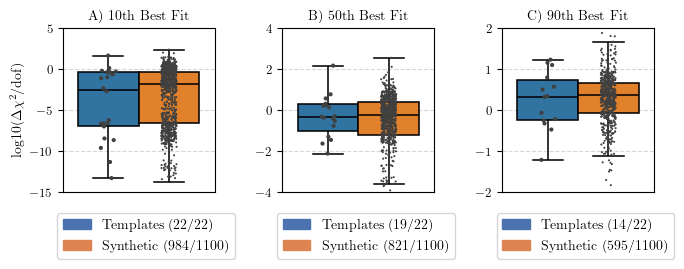

In [96]:
vars = ['gap_p10_per_dof', 'gap_p50_per_dof', 'gap_p90_per_dof']
labels = ['A) 10th Best Fit', 'B) 50th Best Fit', 'C) 90th Best Fit']

fig, axes = plt.subplots(1, 3, figsize=(double_width_mm*mm2in, 80*mm2in))

for var, ax in zip(vars, axes):

    records = []
    for _, row in df.iterrows():
        if pd.isna(row[var]):
            continue
        if row["qTemplate"] == 1:
            records.append({"group": "all templates", "variable": var, "value": row[var]})
        else:
            records.append({"group": "all synthetic", "variable": var, "value": row[var]})
    plot_df = pd.DataFrame(records)

    # count number of valid entries in each group
    [nSynth, nTemp] = plot_df['group'].value_counts()


    # First draw boxplot without fliers
    flierprops_temp = {"marker": "x", "markersize": 0}
    sns.boxplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                linewidth=bp_linewidth, linecolor=bp_linecolor,
                flierprops=flierprops_temp
                )

    # Draw stripplots on top of boxplot
    scatter_color = '0.25'
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=3, dodge=True,
                palette=[scatter_color, "none"]
                )
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=1.5, dodge=True,
                palette=["none", scatter_color]
                )
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, linestyle="--", alpha=0.5)

    # ax.set_ylim(-5, 105)
    
    # ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xticks([])
    ax.set_title(labels[vars.index(var)])

    # ax.set_ylabel("Gap per DOF [log10]")

    handles = [
        mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
        mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
    ]
    by_label = {h.get_label(): h for h in handles}
    leg = ax.legend(by_label.values(), by_label.keys(),
                    loc="lower center", ncol=1,
                    bbox_to_anchor=(0.55, -0.45),
                    # fontsize=4
                    )   



axes[0].set_ylim(-15, 5)
axes[1].set_ylim(-4, 4)
axes[2].set_ylim(-2, 2)

axes[0].set_ylabel("log10($\\Delta\\chi^2$/dof)")

# create legend for the entire figure:
# suptit = plt.suptitle("Objective Value Differences to Best Observed Fit")
# suptit = []

plt.tight_layout()
plt.savefig("StripBoxPlots_Multistart_Fit_Differences.png", dpi=600, bbox_inches='tight', bbox_extra_artists=(leg, ))
plt.savefig("StripBoxPlots_Multistart_Fit-Differences.pdf", bbox_inches='tight', bbox_extra_artists=(leg, ))
plt.show()

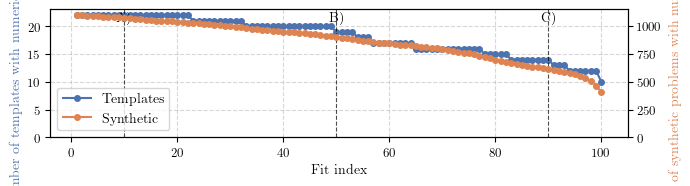

In [108]:
templates = df[df["qTemplate"] == 1]
synthetics = df[df["qTemplate"] == 0]

def fit_value_counts(dataframe, chi2_col="chi2_sorted"):
    max_len = int(dataframe[chi2_col].apply(lambda x: len(np.asarray(x).ravel())).max())
    fit_idx = np.arange(1, max_len + 1)

    counts = []
    for i in fit_idx:
        valid = dataframe[chi2_col].apply(
            lambda x: len(np.asarray(x).ravel()) >= i and np.isfinite(np.asarray(x).ravel()[i - 1])
        ).sum()
        counts.append(valid)

    return fit_idx, np.asarray(counts)

x_t, y_t = fit_value_counts(templates)
x_s, y_s = fit_value_counts(synthetics)

fig, ax1 = plt.subplots(figsize=(double_width_mm * mm2in, 50 * mm2in))
ax2 = ax1.twinx()

l1 = ax1.plot(x_t, y_t, marker="o", lw=1.5, label="Templates", color=sns.color_palette("deep")[0])
l2 = ax2.plot(x_s, y_s, marker="o", lw=1.5, label="Synthetic", color=sns.color_palette("deep")[1])

ax1.set_xlabel("Fit index")
ax1.set_ylabel("Number of templates with numeric fit value", color=sns.color_palette("deep")[0])
ax2.set_ylabel("Number of synthetic problems with numeric fit value", color=sns.color_palette("deep")[1])

ax1.grid(True, linestyle="--", alpha=0.5)

for x_pos, label in zip([10, 50, 90], ["A)", "B)", "C)"]):
    ax1.axvline(x_pos, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax1.text(
        x_pos,
        0.98,
        label,
        transform=ax1.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=fontsize,
    )

ax1.set_ylim(0, max(y_t) * 1.05)
ax2.set_ylim(0, max(y_s) * 1.05)

lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels)

plt.tight_layout()
plt.show()

C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\3234701563.py:122: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\3234701563.py:122: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


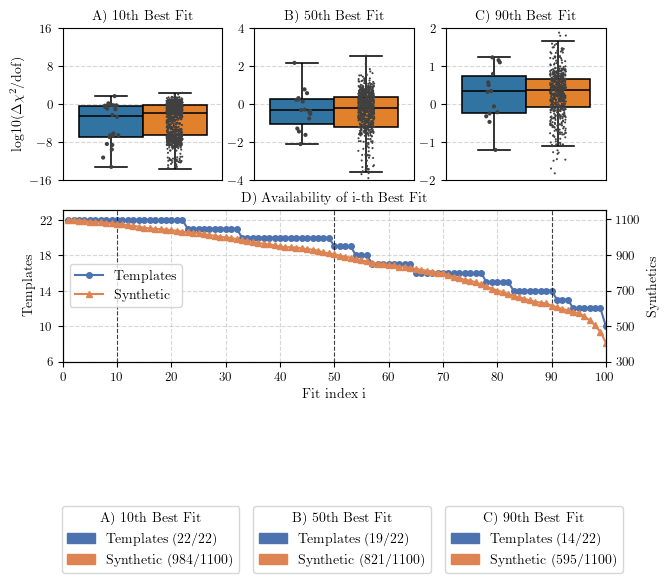

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(double_width_mm * mm2in, 110 * mm2in), constrained_layout=True)

template_color = sns.color_palette("deep")[0]
synthetic_color = sns.color_palette("deep")[1]

top_vars = ['gap_p10_per_dof', 'gap_p50_per_dof', 'gap_p90_per_dof']
top_labels = ['A) 10th Best Fit', 'B) 50th Best Fit', 'C) 90th Best Fit']

# --- Row 1: 10th / 50th / 90th best fit ---
for j, (var, label) in enumerate(zip(top_vars, top_labels)):
    ax = axes[0, j]

    records = []
    for _, row in df.iterrows():
        if pd.isna(row[var]):
            continue
        if row["qTemplate"] == 1:
            records.append({"group": "all templates", "variable": var, "value": row[var]})
        else:
            records.append({"group": "all synthetic", "variable": var, "value": row[var]})
    plot_df = pd.DataFrame(records)

    # count number of valid entries in each group
    [nSynth, nTemp] = plot_df['group'].value_counts()

    plot_df = pd.DataFrame(records)

    sns.boxplot(
        x="variable", y="value", hue="group",
        data=plot_df, ax=ax,
        legend=False, log_scale=False,
        linewidth=bp_linewidth, linecolor=bp_linecolor,
        flierprops={"marker": "x", "markersize": 0}
    )
    sns.stripplot(
        x="variable", y="value", hue="group",
        data=plot_df, ax=ax,
        legend=False, log_scale=False,
        size=3, dodge=True,
        palette=['0.25', 'none']
    )
    sns.stripplot(
        x="variable", y="value", hue="group",
        data=plot_df, ax=ax,
        legend=False, log_scale=False,
        size=1.5, dodge=True,
        palette=['none', '0.25']
    )

    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("" if j > 0 else "log10($\\Delta\\chi^2$/dof)")
    ax.set_xticks([])
    ax.grid(True, linestyle="--", alpha=0.5)

    handles = [
        mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
        mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
    ]
    by_label = {h.get_label(): h for h in handles}
    leg = ax.legend(by_label.values(), by_label.keys(),
                    title=ax.get_title(),
                    loc="lower center", ncol=1,
                    bbox_to_anchor=(0.55, -2.11),
                    # fontsize=4
                    )   

axes[0, 0].set_ylim(-16, 16)
axes[0, 0].set_yticks([-16, -8, 0, 8, 16])
axes[0, 1].set_ylim(-4, 4)
axes[0, 2].set_ylim(-2, 2)

# --- Row 2: availability across fit index ---
# ax1 = axes[1, 0]
# ax2 = ax1.twinx()

# make the second row half the height of the first
# axes[0, 0].get_gridspec().set_height_ratios([2, 1])

# remove bottom-row axes and add a single axis spanning all three columns
gs = axes[0, 0].get_gridspec()
for a in axes[1, :]:
    fig.delaxes(a)
ax1 = fig.add_subplot(gs[1, :])
ax2 = ax1.twinx()

l1 = ax1.plot(x_t, y_t, marker="o", lw=1.5, color=template_color, label="Templates")
l2 = ax2.plot(x_s, y_s, marker="^", lw=1.5, color=synthetic_color, label="Synthetic")

ax1.set_xlim(1, 100)
ax1.set_xticks(np.arange(0, 110, 10))
ax1.set_xlabel("Fit index i")
ax1.set_ylabel("Templates with numeric fit value", color=template_color)
ax2.set_ylabel("Synthetic problems with numeric fit value", color=synthetic_color)
ax1.grid(True, linestyle="--", alpha=0.5)

for x_pos, label_idx in zip([10, 50, 90], range(3)):
    ax1.axvline(x_pos, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    # ax1.text(
    #     x_pos+2, 0.15, top_labels[label_idx].split(")")[0] + ")",
    #     transform=ax1.get_xaxis_transform(),
    #     ha="center", va="top", fontsize=fontsize
    # )

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="center left")

ax1.set_title("D) Availability of i-th Best Fit")
ax1.tick_params(axis='y')
ax2.tick_params(axis='y')
ax1.set_ylabel("Templates", c='k')
ax2.set_ylabel("Synthetics", c='k')

ticks = np.array([6, 10, 14, 18, 22])
ax1.set_yticks(ticks)
ax2.set_yticks(ticks * (1100 / 22))

ax1.set_ylim(min(ticks), max(y_t) * 1.05)
ax2.set_ylim(min(ticks * (1100 / 22)), max(y_s) * 1.05)

plt.tight_layout()
# plt.savefig("StripBoxPlots_Multistart_Fit_Differences_Extended.png", dpi=600, bbox_inches='tight', bbox_extra_artists=(leg, ))
# plt.savefig("StripBoxPlots_Multistart_Fit-Differences_Extended.pdf", bbox_inches='tight', bbox_extra_artists=(leg, ))
plt.show()

C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\1517815528.py:129: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


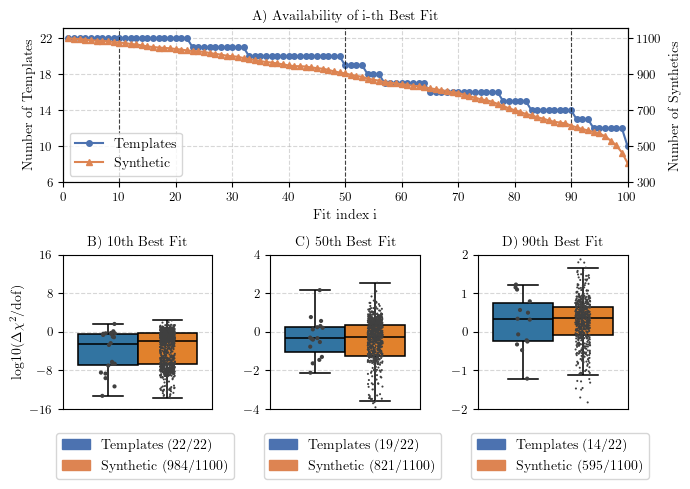

In [216]:
fig, axes = plt.subplots(2, 3, figsize=(double_width_mm * mm2in, 130 * mm2in), constrained_layout=True)

template_color = sns.color_palette("deep")[0]
synthetic_color = sns.color_palette("deep")[1]

top_vars = ['gap_p10_per_dof', 'gap_p50_per_dof', 'gap_p90_per_dof']
top_labels = ['B) 10th Best Fit', 'C) 50th Best Fit', 'D) 90th Best Fit']

# --- Row 1: 10th / 50th / 90th best fit ---
for j, (var, label) in enumerate(zip(top_vars, top_labels)):
    ax = axes[1, j]

    records = []
    for _, row in df.iterrows():
        if pd.isna(row[var]):
            continue
        if row["qTemplate"] == 1:
            records.append({"group": "all templates", "variable": var, "value": row[var]})
        else:
            records.append({"group": "all synthetic", "variable": var, "value": row[var]})
    plot_df = pd.DataFrame(records)

    # count number of valid entries in each group
    [nSynth, nTemp] = plot_df['group'].value_counts()

    plot_df = pd.DataFrame(records)

    sns.boxplot(
        x="variable", y="value", hue="group",
        data=plot_df, ax=ax,
        legend=False, log_scale=False,
        linewidth=bp_linewidth, linecolor=bp_linecolor,
        flierprops={"marker": "x", "markersize": 0}
    )
    sns.stripplot(
        x="variable", y="value", hue="group",
        data=plot_df, ax=ax,
        legend=False, log_scale=False,
        size=3, dodge=True,
        palette=['0.25', 'none']
    )
    sns.stripplot(
        x="variable", y="value", hue="group",
        data=plot_df, ax=ax,
        legend=False, log_scale=False,
        size=1.5, dodge=True,
        palette=['none', '0.25']
    )

    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("" if j > 0 else "log10($\\Delta\\chi^2$/dof)")
    ax.set_xticks([])
    ax.grid(True, linestyle="--", alpha=0.5)

    handles = [
        mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
        mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
    ]
    by_label = {h.get_label(): h for h in handles}
    leg = ax.legend(by_label.values(), by_label.keys(),
                    loc="lower center", ncol=1,
                    bbox_to_anchor=(0.55, -0.5),
                    # fontsize=4
                    )   

# axes[1, 0].set_ylim(-16, 16)
# axes[1, 0].set_yticks([-16, -8, 0, 8, 16])
# axes[1, 1].set_ylim(-4, 4)
# axes[1, 2].set_ylim(-2, 2)

# --- Row 2: availability across fit index ---
# ax1 = axes[1, 0]
# ax2 = ax1.twinx()

# make the second row half the height of the first
# axes[1, 0].get_gridspec().set_height_ratios([2, 1])

# remove bottom-row axes and add a single axis spanning all three columns
gs = axes[0, 0].get_gridspec()
for a in axes[0, :]:
    fig.delaxes(a)
ax1 = fig.add_subplot(gs[0, :])
ax2 = ax1.twinx()

l1 = ax1.plot(x_t, y_t, marker="o", lw=1.5, color=template_color, label="Templates")
l2 = ax2.plot(x_s, y_s, marker="^", lw=1.5, color=synthetic_color, label="Synthetic")

ax1.set_xlim(1, 100)
ax1.set_xticks(np.arange(0, 110, 10))
ax1.set_xlabel("Fit index i")
ax1.set_ylabel("Templates with numeric fit value", color=template_color)
ax2.set_ylabel("Synthetic problems with numeric fit value", color=synthetic_color)
ax1.grid(True, linestyle="--", alpha=0.5)

for x_pos, label_idx in zip([10, 50, 90], range(3)):
    ax1.axvline(x_pos, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    # ax1.text(
    #     x_pos+2, 0.15, top_labels[label_idx].split(")")[0] + ")",
    #     transform=ax1.get_xaxis_transform(),
    #     ha="center", va="top", fontsize=fontsize
    # )

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="lower left")

ax1.set_title("A) Availability of i-th Best Fit")
ax1.tick_params(axis='y')
ax2.tick_params(axis='y')
ax1.set_ylabel("Number of Templates", c='k')
ax2.set_ylabel("Number of Synthetics", c='k')

ticks = np.array([6, 10, 14, 18, 22])
ax1.set_yticks(ticks)
ax2.set_yticks(ticks * (1100 / 22))

ax1.set_ylim(min(ticks), max(y_t) * 1.05)
ax2.set_ylim(min(ticks * (1100 / 22)), max(y_s) * 1.05)

axes[1, 0].set_ylim(-16, 16)
axes[1, 0].set_yticks([-16, -8, 0, 8, 16])
axes[1, 1].set_ylim(-4, 4)
axes[1, 1].set_yticks([-4, -2, 0, 2, 4])
axes[1, 2].set_ylim(-2, 2)
axes[1, 2].set_yticks([-2, -1, 0, 1, 2])


plt.tight_layout()
plt.savefig("StripBoxPlots_Multistart_Fit_Differences_Extended.png", dpi=600, bbox_inches='tight', bbox_extra_artists=(leg, ))
plt.savefig("StripBoxPlots_Multistart_Fit-Differences_Extended.pdf", bbox_inches='tight', bbox_extra_artists=(leg, ))
plt.show()

1008 22
1008 22
1008 22


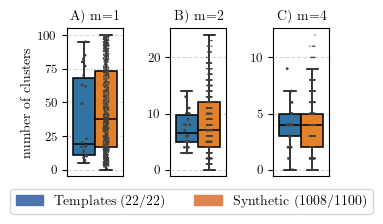

In [214]:
vars = ['n_recurrent_clusters_m1', 'n_recurrent_clusters_m2', 'n_recurrent_clusters_m4']
labels = ['A) m=1', 'B) m=2', 'C) m=4']

fig, axes = plt.subplots(1, 3, figsize=(single_width_mm*mm2in, 50*mm2in))

for var, ax in zip(vars, axes):

    records = []
    for _, row in df.iterrows():
        if pd.isna(row[var]):
            continue
        if row["qTemplate"] == 1:
            records.append({"group": "all templates", "variable": var, "value": row[var]})
        else:
            records.append({"group": "all synthetic", "variable": var, "value": row[var]})
    plot_df = pd.DataFrame(records)

    # count number of valid entries in each group
    [nSynth, nTemp] = plot_df['group'].value_counts()
    print(nSynth, nTemp)


    # First draw boxplot without fliers
    flierprops_temp = {"marker": "x", "markersize": 0}
    sns.boxplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                linewidth=bp_linewidth, linecolor=bp_linecolor,
                flierprops=flierprops_temp
                )

    # Draw stripplots on top of boxplot
    scatter_color = '0.25'
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=2, dodge=True,
                palette=[scatter_color, "none"]
                )
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=1, dodge=True,
                palette=["none", scatter_color]
                )
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, linestyle="--", alpha=0.5)

    # ax.set_ylim(-5, 105)
    
    # ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xticks([])
    ax.set_title(labels[vars.index(var)])

    # ax.set_ylabel("Gap per DOF [log10]")

    # handles = [
    #     mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
    #     mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
    # ]
    # by_label = {h.get_label(): h for h in handles}
    # leg = ax.legend(by_label.values(), by_label.keys(),
    #                 loc="lower center", ncol=1,
    #                 bbox_to_anchor=(0.55, -0.45),
    #                 fontsize=4
    #                 )   



# axes[0].set_ylim(-15, 5)
# axes[1].set_ylim(-4, 4)
# axes[2].set_ylim(-2, 2)

axes[0].set_ylabel("number of clusters")

# create legend for the entire figure:
# plt.suptitle("Objective Value Differences to Best Observed Fit")

handles = [
        mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
        mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
    ]
by_label = {h.get_label(): h for h in handles}
leg = fig.legend(by_label.values(), by_label.keys(),
                 loc="lower center", ncol=2,
                 bbox_to_anchor=(0.55, -0.15)
                )

plt.tight_layout()
# plt.savefig("StripBoxPlots_Multistart.png", dpi=600, bbox_inches='tight', bbox_extra_artists=(leg,))
# plt.savefig("StripBoxPlots_Multistart.pdf", bbox_inches='tight', bbox_extra_artists=(leg,))
plt.show()

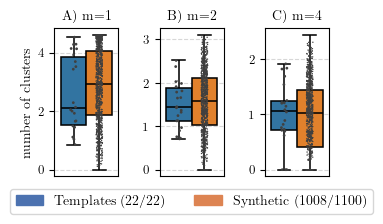

In [98]:
vars = ['cluster_entropy_m1', 'cluster_entropy_m2', 'cluster_entropy_m4']
labels = ['A) m=1', 'B) m=2', 'C) m=4']

fig, axes = plt.subplots(1, 3, figsize=(single_width_mm*mm2in, 50*mm2in))

for var, ax in zip(vars, axes):

    records = []
    for _, row in df.iterrows():
        if pd.isna(row[var]):
            continue
        if row["qTemplate"] == 1:
            records.append({"group": "all templates", "variable": var, "value": row[var]})
        else:
            records.append({"group": "all synthetic", "variable": var, "value": row[var]})
    plot_df = pd.DataFrame(records)

    # count number of valid entries in each group
    [nSynth, nTemp] = plot_df['group'].value_counts()


    # First draw boxplot without fliers
    flierprops_temp = {"marker": "x", "markersize": 0}
    sns.boxplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                linewidth=bp_linewidth, linecolor=bp_linecolor,
                flierprops=flierprops_temp
                )

    # Draw stripplots on top of boxplot
    scatter_color = '0.25'
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=2, dodge=True,
                palette=[scatter_color, "none"]
                )
    sns.stripplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False, log_scale=False,
                size=1, dodge=True,
                palette=["none", scatter_color]
                )
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, linestyle="--", alpha=0.5)

    # ax.set_ylim(-5, 105)
    
    # ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xticks([])
    ax.set_title(labels[vars.index(var)])

    # ax.set_ylabel("Gap per DOF [log10]")

    # handles = [
    #     mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
    #     mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
    # ]
    # by_label = {h.get_label(): h for h in handles}
    # leg = ax.legend(by_label.values(), by_label.keys(),
    #                 loc="lower center", ncol=1,
    #                 bbox_to_anchor=(0.55, -0.45),
    #                 fontsize=4
    #                 )   



# axes[0].set_ylim(-15, 5)
# axes[1].set_ylim(-4, 4)
# axes[2].set_ylim(-2, 2)

axes[0].set_ylabel("number of clusters")

# create legend for the entire figure:
# plt.suptitle("Objective Value Differences to Best Observed Fit")
handles = [
        mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)", ls='-'),
        mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)", linewidth=1)
    ]
by_label = {h.get_label(): h for h in handles}
leg = fig.legend(by_label.values(), by_label.keys(),
                 loc="lower center", ncol=2,
                 bbox_to_anchor=(0.55, -0.15)
                )

plt.tight_layout()
# plt.savefig("StripBoxPlots_Multistart.png", dpi=600, bbox_inches='tight', bbox_extra_artists=(leg,))
# plt.savefig("StripBoxPlots_Multistart.pdf", bbox_inches='tight', bbox_extra_artists=(leg,))
plt.show()

C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\1652982561.py:16: RuntimeWarning: divide by zero encountered in log10
  val = np.log10(row.get(nvar, np.nan))
C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\1652982561.py:16: RuntimeWarning: divide by zero encountered in log10
  val = np.log10(row.get(nvar, np.nan))
C:\Users\neubrand\AppData\Local\Temp\ipykernel_21796\1652982561.py:16: RuntimeWarning: divide by zero encountered in log10
  val = np.log10(row.get(nvar, np.nan))


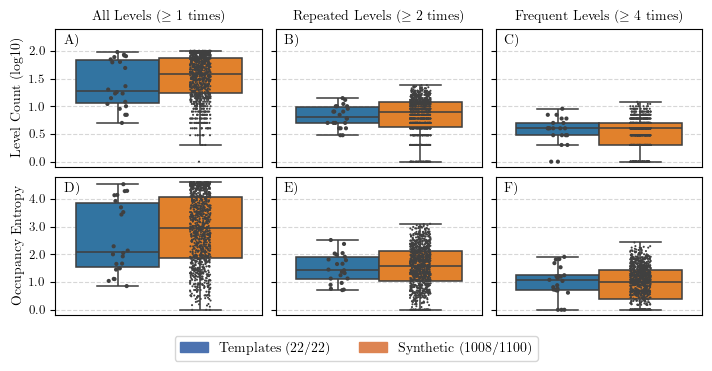

In [105]:
from matplotlib.ticker import FormatStrFormatter

num_vars = ['n_recurrent_clusters_m1', 'n_recurrent_clusters_m2', 'n_recurrent_clusters_m4']
ent_vars = ['cluster_entropy_m1', 'cluster_entropy_m2', 'cluster_entropy_m4']
col_labels = ['All Levels ($\\geq1$ times)', 'Repeated Levels ($\\geq2$ times)', 'Frequent Levels ($\\geq4$ times)']

fig, axes = plt.subplots(2, 3, figsize=(double_width_mm*mm2in, 80*mm2in),
                         constrained_layout=True, sharey='row')
axes = axes.reshape(2, 3)

for j, (nvar, envar, label) in enumerate(zip(num_vars, ent_vars, col_labels)):
    # Top: number of recurrent clusters
    ax = axes[0, j]
    records = []
    for _, row in df.iterrows():
        val = np.log10(row.get(nvar, np.nan))
        if pd.isna(val):
            continue
        grp = "all templates" if row["qTemplate"] == 1 else "all synthetic"
        records.append({"group": grp, "variable": nvar, "value": val})
    plot_df = pd.DataFrame(records)
    nSynth = int(plot_df['group'].value_counts().get('all synthetic', 0))
    nTemp = int(plot_df['group'].value_counts().get('all templates', 0))

    flierprops_temp = {"marker": "x", "markersize": 0}
    sns.boxplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False,
                linewidth=bp_linewidth, color=None,
                flierprops=flierprops_temp)
    sns.stripplot(x="variable", y="value", hue="group",
                  data=plot_df, ax=ax,
                  legend=False, size=3, dodge=True,
                  palette=['0.25', 'none'])
    sns.stripplot(x="variable", y="value", hue="group",
                  data=plot_df, ax=ax,
                  legend=False, size=1.5, dodge=True,
                  palette=['none', '0.25'])

    ax.set_title(label)
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("Level Count (log10)" if j == 0 else "")
    ax.grid(True, linestyle="--", alpha=0.5)

    # Bottom: cluster entropy
    ax = axes[1, j]
    records = []
    for _, row in df.iterrows():
        val = row.get(envar, np.nan)
        if pd.isna(val):
            continue
        grp = "all templates" if row["qTemplate"] == 1 else "all synthetic"
        records.append({"group": grp, "variable": envar, "value": val})
    plot_df = pd.DataFrame(records)

    # reuse counts if zero
    if plot_df.empty:
        nSynth = nSynth if 'nSynth' in locals() else 0
        nTemp = nTemp if 'nTemp' in locals() else 0
    else:
        nSynth = int(plot_df['group'].value_counts().get('all synthetic', 0))
        nTemp = int(plot_df['group'].value_counts().get('all templates', 0))

    sns.boxplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False,
                linewidth=bp_linewidth, flierprops=flierprops_temp)
    sns.stripplot(x="variable", y="value", hue="group",
                  data=plot_df, ax=ax,
                  legend=False, size=3, dodge=True,
                  palette=['0.25', 'none'])
    sns.stripplot(x="variable", y="value", hue="group",
                  data=plot_df, ax=ax,
                  legend=False, size=1.5, dodge=True,
                  palette=['none', '0.25'])

    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("Occupancy Entropy" if j == 0 else "")
    ax.grid(True, linestyle="--", alpha=0.5)


axes[0,0].set_ylim([-0.1, 2.4])
axes[1,0].set_ylim([-0.2, 4.8])

for ax in axes.flat:
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# global legend
handles = [
    mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)"),
    mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)")
]
by_label = {h.get_label(): h for h in handles}
fig.legend(by_label.values(), by_label.keys(), loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.15))

# Add subplot labels to top-left corners
for idx, ax in enumerate(axes.flat):
    ax.text(0.04, 0.96, chr(65 + idx) + ')',
            transform=ax.transAxes, 
            # fontsize=12, fontweight='bold',
            va='top', ha='left')

#fig.suptitle('Recurrent Levels in Final Objective Values')

# plt.savefig("StripBoxPlots_Multistart_Recurrency.png", dpi=600, bbox_inches='tight')
# plt.savefig("StripBoxPlots_Multistart_Recurrency.pdf", bbox_inches='tight')

plt.show()

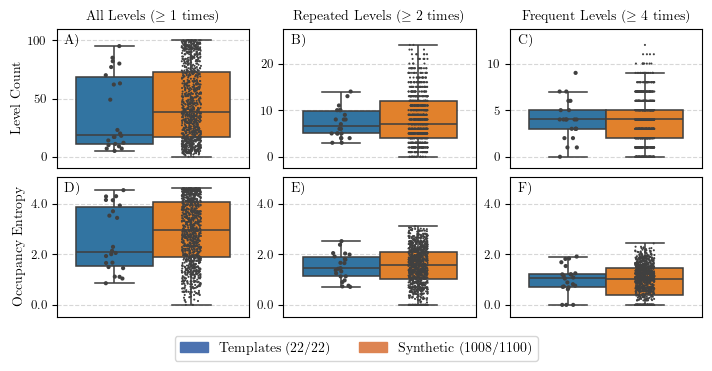

In [194]:
from matplotlib.ticker import FormatStrFormatter

num_vars = ['n_recurrent_clusters_m1', 'n_recurrent_clusters_m2', 'n_recurrent_clusters_m4']
ent_vars = ['cluster_entropy_m1', 'cluster_entropy_m2', 'cluster_entropy_m4']
col_labels = ['All Levels ($\\geq1$ times)', 'Repeated Levels ($\\geq2$ times)', 'Frequent Levels ($\\geq4$ times)']

fig, axes = plt.subplots(2, 3, figsize=(double_width_mm*mm2in, 80*mm2in),
                         constrained_layout=True)
axes = axes.reshape(2, 3)

for j, (nvar, envar, label) in enumerate(zip(num_vars, ent_vars, col_labels)):
    # Top: number of recurrent clusters
    ax = axes[0, j]
    records = []
    for _, row in df.iterrows():
        val = row.get(nvar, np.nan)
        if pd.isna(val):
            continue
        grp = "all templates" if row["qTemplate"] == 1 else "all synthetic"
        records.append({"group": grp, "variable": nvar, "value": val})
    plot_df = pd.DataFrame(records)
    nSynth = int(plot_df['group'].value_counts().get('all synthetic', 0))
    nTemp = int(plot_df['group'].value_counts().get('all templates', 0))

    flierprops_temp = {"marker": "x", "markersize": 0}
    sns.boxplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False,
                linewidth=bp_linewidth, color=None,
                flierprops=flierprops_temp)
    sns.stripplot(x="variable", y="value", hue="group",
                  data=plot_df, ax=ax,
                  legend=False, size=3, dodge=True,
                  palette=['0.25', 'none'])
    sns.stripplot(x="variable", y="value", hue="group",
                  data=plot_df, ax=ax,
                  legend=False, size=1.5, dodge=True,
                  palette=['none', '0.25'])

    ax.set_title(label)
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("Level Count" if j == 0 else "")
    ax.grid(True, linestyle="--", alpha=0.5)

    # Bottom: cluster entropy
    ax = axes[1, j]
    records = []
    for _, row in df.iterrows():
        val = row.get(envar, np.nan)
        if pd.isna(val):
            continue
        grp = "all templates" if row["qTemplate"] == 1 else "all synthetic"
        records.append({"group": grp, "variable": envar, "value": val})
    plot_df = pd.DataFrame(records)

    # reuse counts if zero
    if plot_df.empty:
        nSynth = nSynth if 'nSynth' in locals() else 0
        nTemp = nTemp if 'nTemp' in locals() else 0
    else:
        nSynth = int(plot_df['group'].value_counts().get('all synthetic', 0))
        nTemp = int(plot_df['group'].value_counts().get('all templates', 0))

    sns.boxplot(x="variable", y="value", hue="group",
                data=plot_df, ax=ax,
                legend=False,
                linewidth=bp_linewidth, flierprops=flierprops_temp)
    sns.stripplot(x="variable", y="value", hue="group",
                  data=plot_df, ax=ax,
                  legend=False, size=3, dodge=True,
                  palette=['0.25', 'none'])
    sns.stripplot(x="variable", y="value", hue="group",
                  data=plot_df, ax=ax,
                  legend=False, size=1.5, dodge=True,
                  palette=['none', '0.25'])

    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("Occupancy Entropy" if j == 0 else "")
    ax.grid(True, linestyle="--", alpha=0.5)


def range_with_margin(values, margin=0.1):
    if len(values) == 0:
        return (0, 1)
    vmin, vmax = min(values), max(values)
    if vmin == vmax:
        return (vmin - margin, vmax + margin)
    else:
        return (vmin - margin * (vmax - vmin), vmax + margin * (vmax - vmin))

axes[0,0].set_ylim(range_with_margin([0, 100]))
axes[0,1].set_ylim(range_with_margin([0, 25]))
axes[0,2].set_ylim(range_with_margin([0, 12.5]))

axes[0,0].set_yticks([0, 50, 100])

axes[1,0].set_ylim(range_with_margin([0, 4.6]))
axes[1,1].set_ylim(range_with_margin([0, 4.6]))
axes[1,2].set_ylim(range_with_margin([0, 4.6]))

for ax in axes[0,:]:
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

for ax in axes[1,:]:
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# global legend
handles = [
    mpatches.Patch(color=sns.color_palette("deep")[0], label=f"Templates ({nTemp}/22)"),
    mpatches.Patch(color=sns.color_palette("deep")[1], label=f"Synthetic ({nSynth}/1100)")
]
by_label = {h.get_label(): h for h in handles}
fig.legend(by_label.values(), by_label.keys(), loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.15))

# Add subplot labels to top-left corners
for idx, ax in enumerate(axes.flat):
    ax.text(0.04, 0.96, chr(65 + idx) + ')',
            transform=ax.transAxes, 
            # fontsize=12, fontweight='bold',
            va='top', ha='left')

#fig.suptitle('Recurrent Levels in Final Objective Values')

plt.savefig("StripBoxPlots_Multistart_Recurrency.png", dpi=600, bbox_inches='tight')
plt.savefig("StripBoxPlots_Multistart_Recurrency.pdf", bbox_inches='tight')

plt.show()

## Legend Snippets

### Template Names

In [37]:
# 'import matplotlib.patches as mpatches

# fig, ax = plt.subplots(figsize=(1, 1))
# ax.axis("off")

# # Create legend handles for each template name and color
# handles = [
#     mpatches.Patch(color=colorDict[t], label=t)
#     for t in templateNames
# ]

# # Add legend to the figure
# legend = ax.legend(handles=handles,
#                    title="Template Names",
#                    ncol=2,
#                    frameon=False,
#                    title_fontsize=4,
#                    fontsize=4,
#                    alignment="left",
#                    columnspacing=1,
#                    labelspacing=0.2
#                    )

# legend._legend_box.sep = 3

# # Adjust figure size
# fig.canvas.draw()
# bbox = legend.get_window_extent()
# width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
# fig.set_size_inches(width, height)

# plt.tight_layout(pad=0, h_pad=0, w_pad=0)
# plt.savefig("PCA_ProblemSpace_Legend_Templates.png", dpi=600, bbox_inches='tight', transparent=True)
# plt.savefig("PCA_ProblemSpace_Legend_Templates.pdf", dpi=600, bbox_inches='tight', transparent=True)'

In [38]:
# import matplotlib.patches as mpatches
# plt.rcParams["text.latex.preamble"] = r"\usepackage{calc}\usepackage{pifont}"


# fig, ax = plt.subplots(figsize=(1, 1))
# ax.axis("off")

# # Create legend handles for each template name and color
# handles = [
#     mpatches.Patch(color=colorDict[t], label=t)
#     for t in templateNames
# ]

# # Modify handles to include counts of included synthetics for each template
# handles = []
# for (id, t) in enumerate(templateNames):
#     mask = df.loc[df_pca.index, "templateName"] == t

#     is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
#     is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask
    
#     template_included = is_template.sum()
#     synthetic_count = is_synthetic.sum()

#     # label = (
#     #     f"{t:<20s}"
#     #     f"({'\\ding{51}' if template_included > 0 else '\\ding{55}'}, "
#     #     f"{synthetic_count})"
#     # )
#     longest_name = "Brannmark" if id <= 10 else "Swameye"
#     ding_ref = r"\ding{51}"

#     mark = r"\ding{51}" if template_included > 0 else r"\ding{55}"

#     label = (
#         rf"\makebox[\widthof{{{longest_name}}}][l]{{{t}}}"
#         rf"\,(\makebox[\widthof{{\ding{{51}}}}][c]{{{mark}}},\,{synthetic_count})"
#     )

    
#     handles.append(mpatches.Patch(color=colorDict[t], label=label))



# # Add legend to the figure
# legend = ax.legend(handles=handles,
#                    title="Template Names",
#                    ncol=2,
#                    frameon=False,
#                    title_fontsize=4,
#                    fontsize=4,
#                    alignment="left",
#                    columnspacing=1,
#                    labelspacing=0.2
#                    )




# legend._legend_box.sep = 3

# # Adjust figure size
# fig.canvas.draw()
# bbox = legend.get_window_extent()
# width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
# fig.set_size_inches(width, height)

# plt.tight_layout(pad=0, h_pad=0, w_pad=0)
# plt.savefig("PCA_ProblemSpace_Legend_Templates_Numbers.png", dpi=600, bbox_inches='tight', transparent=True)
# plt.savefig("PCA_ProblemSpace_Legend_Templates_Numbers.pdf", dpi=600, bbox_inches='tight', transparent=True)

In [39]:
# import matplotlib.patches as mpatches
# plt.rcParams["text.latex.preamble"] = r"\usepackage{calc}\usepackage{pifont}"


# fig, ax = plt.subplots(figsize=(1, 1))
# ax.axis("off")

# # Create legend handles with counts of included synthetics for each template
# handles = []
# for (id, t) in enumerate(templateNames):
#     mask = df.loc[df_pca.index, "templateName"] == t

#     is_template = (df.loc[df_pca.index, "qTemplate"] == 1) & mask
#     is_synthetic = (df.loc[df_pca.index, "qTemplate"] == 0) & mask
    
#     template_included = is_template.sum()
#     synthetic_count = is_synthetic.sum()

#     # label = (
#     #     f"{t:<20s}"
#     #     f"({'\\ding{51}' if template_included > 0 else '\\ding{55}'}, "
#     #     f"{synthetic_count})"
#     # )
#     longest_name = "Brannmark"
#     ding_ref = r"\ding{51}"
#     spacer=r"\hspace{2mm}"

#     mark = r"\ding{51}" if template_included > 0 else r"\ding{55}"

#     label = (
#         rf"\makebox[\widthof{{{longest_name}}}][l]{{{t}}}"
#         rf"\hspace{{4.5mm}}\makebox[\widthof{{\ding{{51}}}}][c]{{{mark}}}{spacer}{synthetic_count}"
#     )

    
#     handles.append(mpatches.Patch(color=colorDict[t], label=label))



# # Add legend to the figure
# legend = ax.legend(handles=handles,
#                    title=r"Template Colors \& Inclusion",
#                    ncol=1,
#                    frameon=False,
#                    title_fontsize=4,
#                    fontsize=4,
#                    alignment="left",
#                    columnspacing=1,
#                    labelspacing=0.
#                    )




# legend._legend_box.sep = 3

# # Adjust figure size
# fig.canvas.draw()
# bbox = legend.get_window_extent()
# width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
# fig.set_size_inches(width, height)

# plt.tight_layout(pad=0, h_pad=0, w_pad=0)
# plt.savefig("PCA_ProblemSpace_Legend_Templates_Numbers_V2.png", dpi=600, bbox_inches='tight', transparent=True)
# plt.savefig("PCA_ProblemSpace_Legend_Templates_Numbers_V2.pdf", dpi=600, bbox_inches='tight', transparent=True)

In [40]:
# fig, ax = plt.subplots(figsize=(1, 0.5))
# ax.axis("off")

# # Create legend handles for each template name and color
# handles = [
#     mpatches.Patch(color=colorDict[t], label=t)
#     for t in templateNames
# ]

# # Add legend to the figure
# legend = ax.legend(handles=handles,
#                    title="Template Names",
#                    ncol=5,
#                    frameon=False,
#                    title_fontsize=5,
#                    fontsize=3,
#                    alignment="left",
#                    columnspacing=1,
#                    # labelspacing=0.4
#                    )

# legend._legend_box.sep = 5

# # Adjust figure size
# fig.canvas.draw()
# bbox = legend.get_window_extent()
# width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
# fig.set_size_inches(width, height)

# plt.tight_layout(pad=0, h_pad=0, w_pad=0)
# plt.savefig("PCA_ProblemSpace_Legend_Templates_V2.png", dpi=600, bbox_inches='tight', transparent=True)
# plt.savefig("PCA_ProblemSpace_Legend_Templates_V2.pdf", dpi=600, bbox_inches='tight', transparent=True)

In [41]:
# fig, ax = plt.subplots(figsize=(1, 0.5))
# ax.axis("off")

# # Create dummy legend handles for template and synthetic
# template_handle = plt.Line2D([], [], color="gray", marker="o", linestyle="None",
#                              markeredgewidth=template_lw,
#                             markersize=np.sqrt(template_marker_size), markeredgecolor=template_edge_color, label="Template")
# synthetic_handle = plt.Line2D([], [], color="gray", marker="o", linestyle="None",
#                               markersize=np.sqrt(synthetic_marker_size), markeredgecolor="none", label="Synthetic")

# handles = [template_handle, synthetic_handle]

# legend = ax.legend(handles=handles,
#                    title="Marker Types",
#                    ncol=2,
#                    title_fontsize=4,
#                    fontsize=4,
#                    frameon=False,
#                    alignment="left",
#                    columnspacing=1.5,
#                    labelspacing=0.2
#                    )

# legend._legend_box.sep = 3

# # Adjust figure size
# fig.canvas.draw()
# bbox = legend.get_window_extent()
# width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
# fig.set_size_inches(width, height)


# plt.tight_layout()
# plt.savefig("PCA_ProblemSpace_Legend_Markers.png", dpi=600, bbox_inches='tight', transparent=True)
# plt.savefig("PCA_ProblemSpace_Legend_Markers.pdf", dpi=600, bbox_inches='tight', transparent=True)

#### Summary Stats

In [42]:
# import matplotlib.patches as mpatches

# fig, ax = plt.subplots(figsize=(1, 1))
# ax.axis("off")

# # Create legend handles for each template name and color
# handles = [
#     mpatches.Patch(color=colorDict[t], label=t)
#     for t in templateNames
# ]

# # Add legend to the figure
# legend = ax.legend(handles=handles,
#                    title="Template Names",
#                    ncol=3,
#                    frameon=False,
#                    title_fontsize=5,
#                    fontsize=4,
#                    alignment="left"
#                    )

# legend._legend_box.sep = 5

# # Adjust figure size
# fig.canvas.draw()
# bbox = legend.get_window_extent()
# width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
# fig.set_size_inches(width, height)

# plt.tight_layout()
# plt.savefig("Summary_Stats_Legend_Templates.png", dpi=600, bbox_inches='tight', transparent=True)
# plt.savefig("Summary_Stats_Legend_Templates.pdf", dpi=600, bbox_inches='tight', transparent=True)

In [43]:
# fig, ax = plt.subplots(figsize=(2, 1))
# ax.axis("off")

# # Create dummy legend handles for template and synthetic markers
# template_handle = plt.Line2D([], [], color="gray", marker="o", linestyle="None",
#                              markeredgewidth=template_lw,
#                              markersize=np.sqrt(template_marker_size), markeredgecolor=template_edge_color, label="Template")

# handles = [template_handle] #, synthetic_handle, synthetic_handle_pooled]
# legend = ax.legend(handles=handles,
#                    handler_map={tuple: HandlerTuple(ndivide=None)},
#                    labels=["Templates"],
#                    title="Marker Types",
#                    loc="center",
#                    ncol=1,
#                    title_fontsize=5,
#                    fontsize=4,
#                    frameon=False,
#                    alignment="left",
#                    handletextpad=2
#                    )

# legend._legend_box.sep = 5

# # Adjust figure size
# fig.canvas.draw()
# bbox = legend.get_window_extent()
# width, height = bbox.width / fig.dpi, bbox.height / fig.dpi
# fig.set_size_inches(width, height)


# plt.tight_layout()
# plt.savefig("SummaryStats_Legend_Markers.png", dpi=600, bbox_inches='tight')
# plt.savefig("SummaryStats_Legend_Markers.pdf", dpi=600, bbox_inches='tight')

In [44]:
# # fig, ax = plt.subplots(figsize=(0.2, 0.38))
# fig, ax = plt.subplots(figsize=(0.2, 0.25))
# ax.axis("off")

# # Example data for boxplot
# data = np.concatenate([np.zeros(30), np.ones(20), 3* np.ones(20), -3*np.ones(20), -1 * np.ones(20), [ -4.1, 4.1 ]])

# # Draw gray boxplot

# dummy_color = 'gray'
# bp = ax.boxplot(
#             data,
#             # positions=[1],
#             widths=bp_width,  # relative box width (adjust as needed)
#             patch_artist=True,
#             boxprops=dict(facecolor=dummy_color, alpha=0.6, color='none'),
#             whiskerprops=dict(color=dummy_color, alpha=1, lw=0.5),
#             capprops=dict(color=dummy_color, alpha=1, lw=0.5),
#             medianprops=dict(color=dummy_color, lw=1),
#             flierprops=dict(marker='.',
#                             markerfacecolor=dummy_color,
#                             markeredgecolor=dummy_color,
#                             alpha=1, markersize=2
#                             )
# )

# ax.set_ylim(-5, 5)

# ax.annotate("Synthetics Per-Template", xy=(1.6, 0.5), xycoords="axes fraction",
#             ha="left", va="center", fontsize=4, color="black")

# ax.set_xticks([])
# ax.set_yticks([])
# plt.tight_layout(pad=0, w_pad=0, h_pad=0)
# plt.savefig("gray_boxplot_snippet.png", dpi=300, bbox_inches='tight', transparent=True)
# plt.savefig("gray_boxplot_snippet.pdf", dpi=300, bbox_inches='tight', transparent=True)

In [45]:
# # fig, ax = plt.subplots(figsize=(0.2, 0.38))
# fig, ax = plt.subplots(figsize=(0.2, 0.25))
# ax.axis("off")

# # Example data for boxplot
# data = np.concatenate([np.zeros(30), np.ones(20), 3* np.ones(20), -3*np.ones(20), -1 * np.ones(20), [ -4.1, 4.1 ]])
# bp_stats_data = boxplot_stats(data)

# bp_stats_data = {'median': 0.0,
#  'q1': -1.0,
#  'q3': 1.0,
#  'iqr': 2.0,
#  'lower_whisker': -2.0,
#  'upper_whisker': 2.0,
#  'fliers': np.array([-4.1,  4.1]),
#  'min': -4.1,
#  'max': 4.1}


# # Draw gray boxplot

# synth_color = "gray"
# synth_color_fill = "lightgray"

# quartile_alpha = 0.8
# quartile_lw = 0.5
# whisker_alpha = 0.3
# whisker_lw = 0.5
# whisker_ls = ':'


# ax.axhline(bp_stats_data['median'],
#                 color=synth_color,
#                 linestyle='-', lw=1.5,
#                 zorder=-4)
# ax.axhline(bp_stats_data['q1'], color=synth_color, linestyle='-', lw=quartile_lw, zorder=-5)
# ax.axhline(bp_stats_data['q3'], color=synth_color, linestyle='-', lw=quartile_lw, zorder=-5)
# ax.axhline(bp_stats_data['lower_whisker'], color=synth_color, linestyle=whisker_ls, lw=whisker_lw, zorder=-5)
# ax.axhline(bp_stats_data['upper_whisker'], color=synth_color, linestyle=whisker_ls, lw=whisker_lw, zorder=-5)
# ax.fill_between([lims[var][0], lims[var][1]],
#                 bp_stats_data['q1'], bp_stats_data['q3'],
#                 color=synth_color_fill, alpha=quartile_alpha,
#                 lw=0,
#                 zorder=-6)
# ax.fill_between([lims[var][0], lims[var][1]],
#                 bp_stats_data['lower_whisker'], bp_stats_data['upper_whisker'],
#                 color=synth_color_fill, alpha=whisker_alpha,
#                 lw=0,
#                 zorder=-6)

# ax.set_ylim(-3.5, 3.5)

# ax.annotate("Synthetics All Pooled", xy=(1.6, 0.5), xycoords="axes fraction",
#             ha="left", va="center", fontsize=4, color="black")

# ax.set_xticks([])
# ax.set_yticks([])
# plt.tight_layout(pad=0, w_pad=0, h_pad=0)
# plt.savefig("gray_background_snippet.png", dpi=300, bbox_inches='tight', transparent=True)
# plt.savefig("gray_background_snippet.pdf", dpi=300, bbox_inches='tight', transparent=True)